In [88]:
import numpy as np
import pandas as pd

In [89]:
df = pd.read_csv("spam.csv", encoding="latin-1")

In [90]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
931,ham,Congratulations ore mo owo re wa. Enjoy it and...,NaN,NaN,NaN
2223,spam,"Thanks for your ringtone order, ref number K71...",NaN,NaN,NaN
4625,ham,Lol ... I knew that .... I saw him in the doll...,NaN,NaN,NaN
121,ham,here is my new address -apples&pairs&all that ...,NaN,NaN,NaN
4090,ham,Hey doc pls I want to get nice t shirt for my ...,NaN,NaN,NaN


In [91]:
df.shape

(5572, 5)

In [92]:
#Data cleaning
#EDA
#Text processing 
#Model building 
#Evaluation
#Improvement
#Website
#Deploy

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [94]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [95]:
df.sample(5)

,v1,v2
4323,ham,I am not having her number sir
5520,ham,No. I dont want to hear anything
1303,ham,I cant pick the phone right now. Pls send a me...
5093,ham,Gokila is talking with you aha:)
3452,ham,Nowadays people are notixiquating the laxinorf...


In [96]:
#renaming function
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [97]:
df.sample(5)

,target,text
3240,ham,Ok i've sent u da latest version of da project.
4174,ham,How are you doing. How's the queen. Are you go...
68,spam,"Did you hear about the new \Divorce Barbie\""? ..."
473,spam,Want 2 get laid tonight? Want real Dogging loc...
255,ham,Don't necessarily expect it to be done before ...


In [98]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [99]:
df['target'] = encoder.fit_transform(df['target'])

In [100]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [101]:
#missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [102]:
#check for duplicates
df.duplicated().sum()

np.int64(403)

In [103]:
#remove duplicate
df = df.drop_duplicates(keep='first')

In [104]:
df.duplicated().sum()

np.int64(0)

In [105]:
df.shape

(5169, 2)

In [106]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

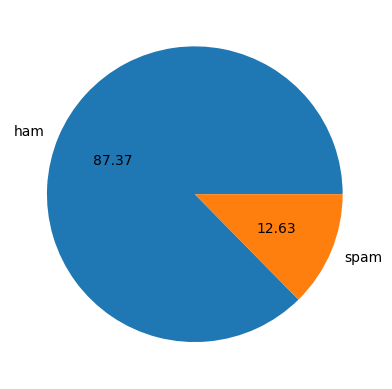

In [107]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [108]:
#Data is imbalanced

In [109]:
import nltk

In [110]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /Users/amit/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/amit/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [111]:
df['num_characters'] = df['text'].apply(len)

In [112]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [113]:
#num of words
df['num_word'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [114]:
df.head()

,target,text,num_characters,num_word
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [115]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [116]:
df.head()

,target,text,num_characters,num_word,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [117]:
df[['num_characters','num_word','num_sentences']].describe()

,num_characters,num_word,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [118]:
#ham
df[df['target'] == 0] [['num_characters','num_word','num_sentences']].describe()

,num_characters,num_word,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [119]:
#spam
df[df['target'] == 1] [['num_characters','num_word','num_sentences']].describe()


,num_characters,num_word,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [120]:
import seaborn as sns


<Axes: xlabel='num_characters', ylabel='Count'>

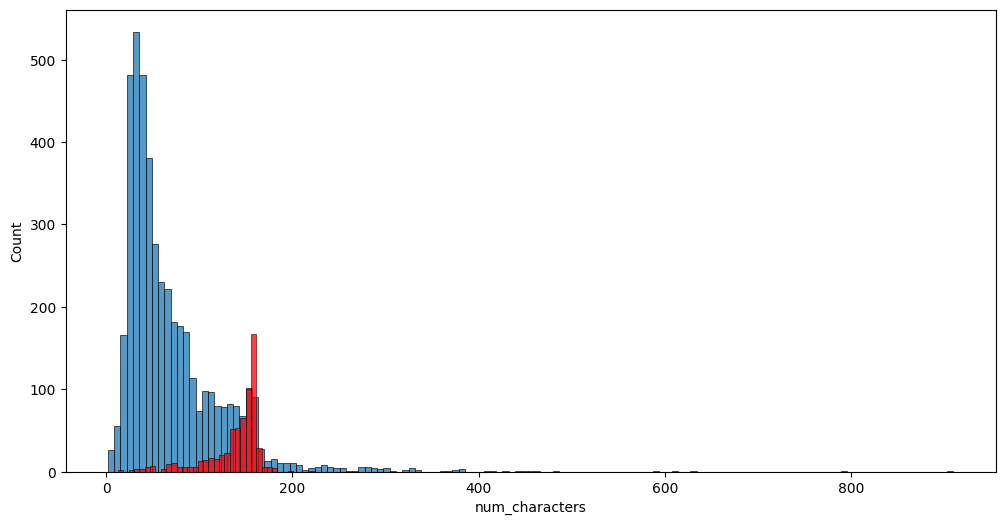

In [121]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

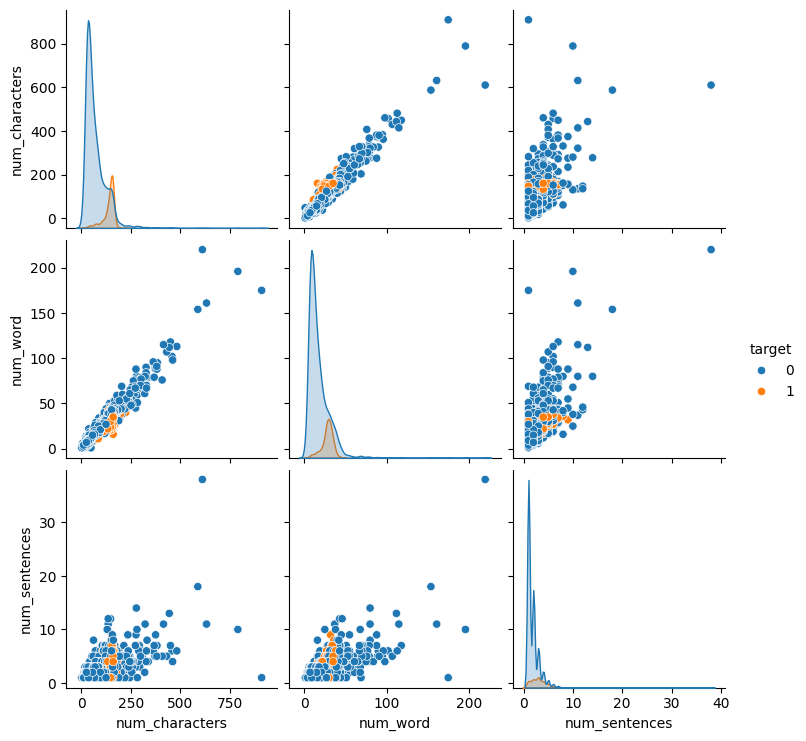

In [122]:
sns.pairplot(df,hue='target')

<Axes: >

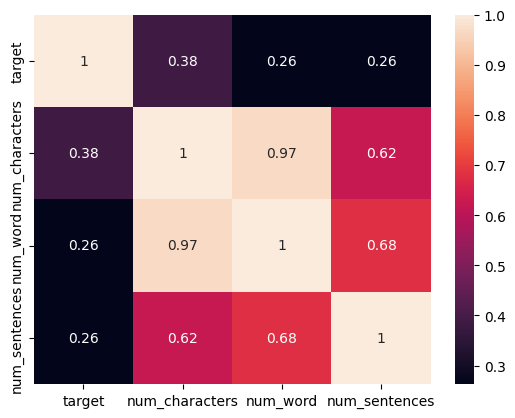

In [123]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [124]:
#Data Preprocessing
#01. lower case
#02. tokrnization
#03. removing special characters
#04. removing stop words and punctuation
#05. stemming

In [125]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
 
    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

In [126]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /Users/amit/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [127]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [128]:
import string
import nltk
from nltk.corpus import stopwords

In [129]:
df['text'][20]

'Is that seriously how you spell his name?'

In [130]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dancing')

'danc'

In [131]:
df['transformed_text']=df['text'].apply(transform_text)

In [132]:
transform_text('Is that seriously how you spell his name?')

'serious spell name'

In [133]:
df.head()

,target,text,num_characters,num_word,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [134]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')


In [135]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

<Figure size 1600x800 with 0 Axes>

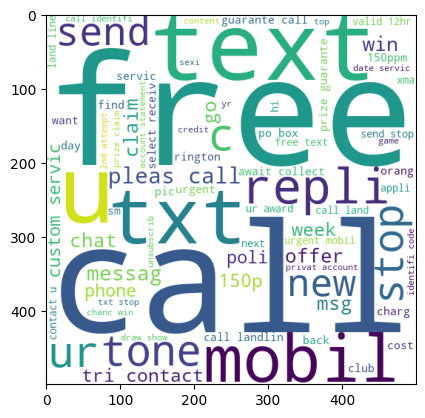

<Figure size 1600x800 with 0 Axes>

In [136]:
plt.imshow(spam_wc)
plt.figure(figsize=(16,8))

In [137]:
ham_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

<Figure size 1600x800 with 0 Axes>

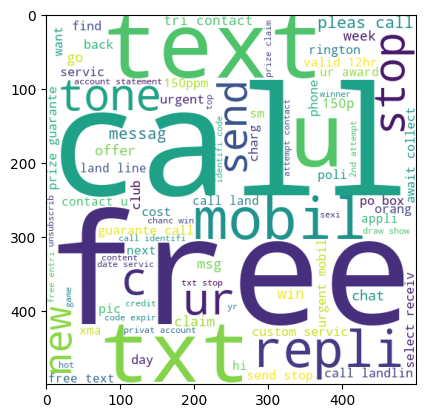

<Figure size 1600x800 with 0 Axes>

In [138]:
plt.imshow(ham_wc)
plt.figure(figsize=(16,8))

In [139]:
spam_corpus = []
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
        

In [140]:
len(spam_corpus)

9939

In [141]:
from collections import Counter


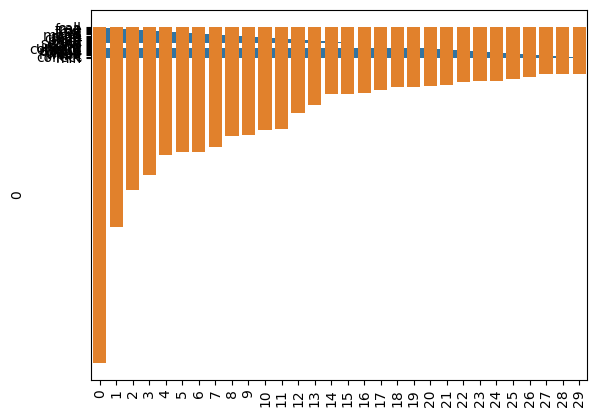

In [142]:
sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[0])
sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [143]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [144]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [145]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [146]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5169, 3000))

In [147]:
X.shape

(5169, 3000)

In [148]:
y = df['target'].values

In [149]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [150]:
from sklearn.model_selection import train_test_split


In [151]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=2)

In [152]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [153]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [154]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8723404255319149
[[782 114]
 [ 18 120]]
0.5128205128205128


In [155]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9787234042553191
[[889   7]
 [ 15 123]]
0.9461538461538461


In [156]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [157]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier

In [158]:
svc = SVC(kernel='sigmoid', gamma=1.0)

knc = KNeighborsClassifier()

mnb = MultinomialNB()

dtc = DecisionTreeClassifier(max_depth=5)

lr = LogisticRegression(solver='liblinear', penalty='l1')

rfc = RandomForestClassifier(n_estimators=50, random_state=2)

abc = AdaBoostClassifier(n_estimators=50, random_state=2)

bc = BaggingClassifier(n_estimators=50, random_state=2)

etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)

xgb = XGBClassifier(n_estimators=50, random_state=2)

In [159]:
clfs = {
    'SVC': svc,
    'KNN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lr,
    'RF': rfc,
    'AdaBoost': abc,
    'Bagging': bc,
    'ExtraTrees': etc,
    'GBDT': gbdt,
    'XGBoost': xgb
}

In [160]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    
    return accuracy, precision

In [161]:
train_classifier(svc, X_train, y_train, X_test, y_test)

(0.9690522243713733, 0.9274193548387096)

In [162]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(
        clf, X_train, y_train, X_test, y_test
    )

    print("For:", name)
    print("Accuracy:", current_accuracy)
    print("Precision:", current_precision)
    print("-" * 30)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For: SVC
Accuracy: 0.9690522243713733
Precision: 0.9274193548387096
------------------------------
For: KNN
Accuracy: 0.9052224371373307
Precision: 0.9761904761904762
------------------------------
For: NB
Accuracy: 0.9787234042553191
Precision: 0.9461538461538461
------------------------------
For: DT
Accuracy: 0.9274661508704062
Precision: 0.8118811881188119
------------------------------
For: LR
Accuracy: 0.9671179883945842
Precision: 0.9642857142857143
------------------------------


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For: RF
Accuracy: 0.9758220502901354
Precision: 0.9829059829059829
------------------------------
For: AdaBoost
Accuracy: 0.9245647969052224
Precision: 0.8488372093023255
------------------------------
For: Bagging
Accuracy: 0.9584139264990329
Precision: 0.8682170542635659
------------------------------
For: ExtraTrees
Accuracy: 0.9748549323017408
Precision: 0.9745762711864406
------------------------------
For: GBDT
Accuracy: 0.9468085106382979
Precision: 0.9191919191919192
------------------------------
For: XGBoost
Accuracy: 0.9671179883945842
Precision: 0.9482758620689655
------------------------------


In [163]:
performance_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
})

In [164]:
performance_df

,Algorithm,Accuracy,Precision
0,SVC,0.969052,0.927419
1,KNN,0.905222,0.976190
2,NB,0.978723,0.946154
3,DT,0.927466,0.811881
4,LR,0.967118,0.964286
5,RF,0.975822,0.982906
6,AdaBoost,0.924565,0.848837
7,Bagging,0.958414,0.868217
8,ExtraTrees,0.974855,0.974576
9,GBDT,0.946809,0.919192


In [165]:
performance_df1 = pd.melt(performance_df, id_vars="Algorithm")

In [166]:
performance_df1

,Algorithm,variable,value
0,SVC,Accuracy,0.969052
1,KNN,Accuracy,0.905222
2,NB,Accuracy,0.978723
3,DT,Accuracy,0.927466
4,LR,Accuracy,0.967118
5,RF,Accuracy,0.975822
6,AdaBoost,Accuracy,0.924565
7,Bagging,Accuracy,0.958414
8,ExtraTrees,Accuracy,0.974855
9,GBDT,Accuracy,0.946809


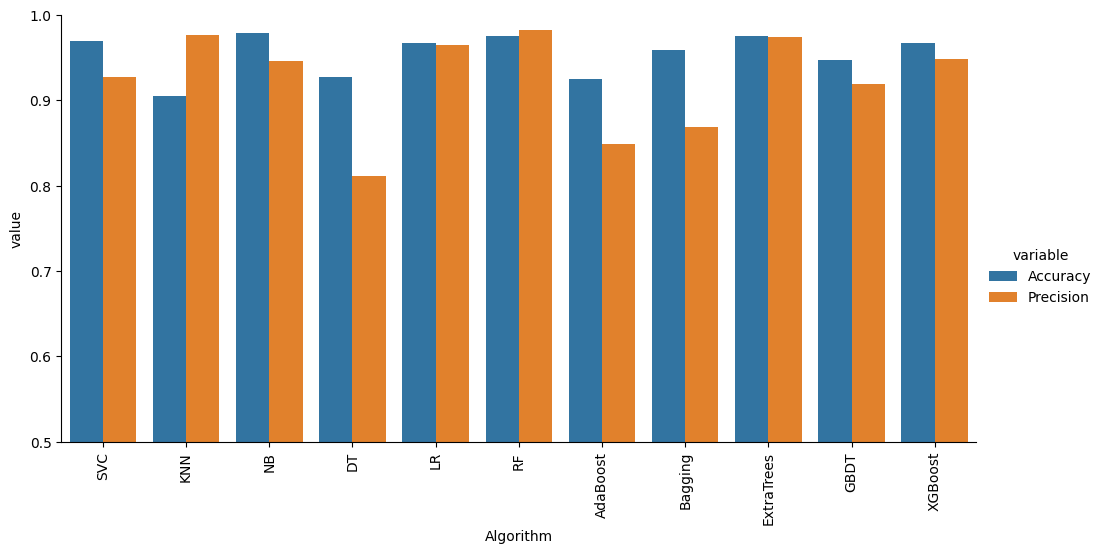

In [167]:
sns.catplot(
    x='Algorithm',
    y='value',
    hue='variable',
    data=performance_df1,
    kind='bar',
    height=5,
    aspect=2
)

plt.ylim(0.5, 1.0)
plt.xticks(rotation=90)
plt.show()

In [168]:
temp_df = pd.DataFrame({
    'Algorithm': list(clfs.keys()),
    'Accuracy_max_ft_3000': accuracy_scores,
    'Precision_max_ft_3000': precision_scores
})

performance_df = performance_df.merge(temp_df, on='Algorithm', how='inner')

In [169]:
performance_df

,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000
0,SVC,0.969052,0.927419,0.969052,0.927419
1,KNN,0.905222,0.976190,0.905222,0.976190
2,NB,0.978723,0.946154,0.978723,0.946154
3,DT,0.927466,0.811881,0.927466,0.811881
4,LR,0.967118,0.964286,0.967118,0.964286
5,RF,0.975822,0.982906,0.975822,0.982906
6,AdaBoost,0.924565,0.848837,0.924565,0.848837
7,Bagging,0.958414,0.868217,0.958414,0.868217
8,ExtraTrees,0.974855,0.974576,0.974855,0.974576
9,GBDT,0.946809,0.919192,0.946809,0.919192


In [170]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))